In [8]:
import pandas as pd

import warnings

# 忽略所有警告訊息
warnings.filterwarnings('ignore')

# 設定顯示選項，確保能看到所有欄位 (避免出現 ...)
pd.set_option('display.max_columns', None)

# 1. 讀取資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

# 2. 列出所有欄位名稱與型態
print(f"專案總欄位數：{df.shape[1]}")
print("-" * 30)
print("【所有欄位及其資料型態清單】")
print(df.dtypes)

專案總欄位數：103
------------------------------
【所有欄位及其資料型態清單】
RaceEth                   float64
HowOldAreYou              float64
WhatIsYourSex             float64
InWhatGradeAreYou         float64
AreYouHispanicOrLatino    float64
                           ...   
HealthInGeneral           float64
BMIPCT                    float64
weight                    float64
stratum                     int64
psu                         int64
Length: 103, dtype: object


In [9]:
# 計算全表缺失值
full_missing = df.isnull().sum()
full_missing_pct = (full_missing / len(df)) * 100

# 建立完整缺失值報告，並按缺失比例由高到低排序
missing_report = pd.DataFrame({
    '缺失筆數': full_missing,
    '缺失比例 (%)': full_missing_pct
}).sort_values(by='缺失比例 (%)', ascending=False)

print("【全表缺失值排序報告 (前 20 名)】")
print(missing_report.head(20))

【全表缺失值排序報告 (前 20 名)】
                          缺失筆數   缺失比例 (%)
WhatIsYourRace            2147  15.290934
UsedMotorcycleHelmet      2072  14.756784
SunProtection             2013  14.336586
HIVTesting                1921  13.681362
Sleep                     1887  13.439214
SunscreenUse              1882  13.403604
InjuredWhileExercising    1863  13.268286
HealthInGeneral           1848  13.161456
MinutesInPEPlayingSports  1846  13.147212
EverUsedLSD               1729  12.313938
InjuriousSuicide          1715  12.214230
AttemptedSuicide          1557  11.088954
NoerobicExercise          1548  11.024856
AerobicExercise           1530  10.896660
HowObtainedCigarettes     1430  10.184460
CurrentAlcoholUse         1372   9.771384
SourceOfAlcohol           1267   9.023574
EverAlcoholUse            1233   8.781426
BirthControlPillUse       1186   8.446692
CondomUse                 1135   8.083470


In [10]:
# 取得所有數值型欄位的統計摘要
full_desc = df.describe()

print("【全表數值欄位統計摘要】")
print(full_desc)

# 檢查是否有任何欄位是完全空的
empty_cols = df.columns[df.isnull().all()].tolist()
print(f"\n完全空白的欄位：{empty_cols if empty_cols else '無'}")

【全表數值欄位統計摘要】
            RaceEth  HowOldAreYou  WhatIsYourSex  InWhatGradeAreYou  \
count  13793.000000  13980.000000   14028.000000       13972.000000   
mean       4.888059      5.131617       1.498432           2.509090   
std        1.551166      1.229040       0.500015           1.121361   
min        1.000000      1.000000       1.000000           1.000000   
25%        3.000000      4.000000       1.000000           2.000000   
50%        5.000000      5.000000       1.000000           3.000000   
75%        6.000000      6.000000       2.000000           4.000000   
max        8.000000      7.000000       2.000000           5.000000   

       AreYouHispanicOrLatino  HowTallAreYouWithoutShoesInMeters  \
count            13859.000000                       13062.000000   
mean                 1.719821                           1.694038   
std                  0.449103                           0.101466   
min                  1.000000                           1.270000   
25%    

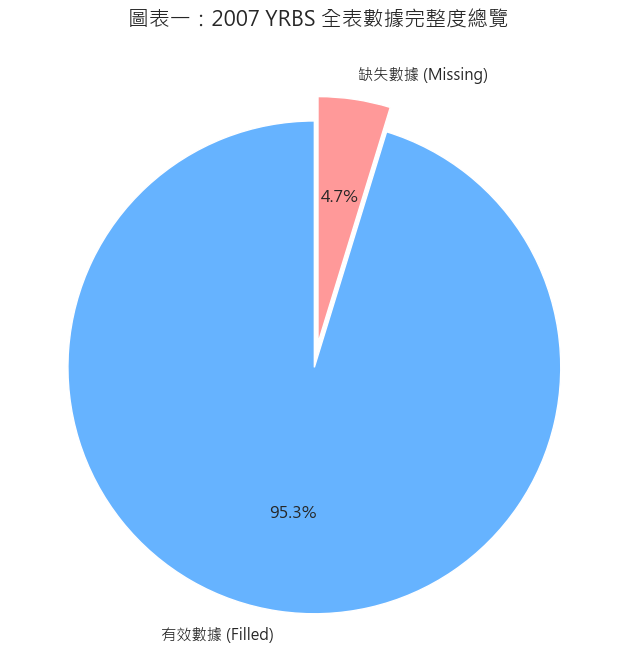

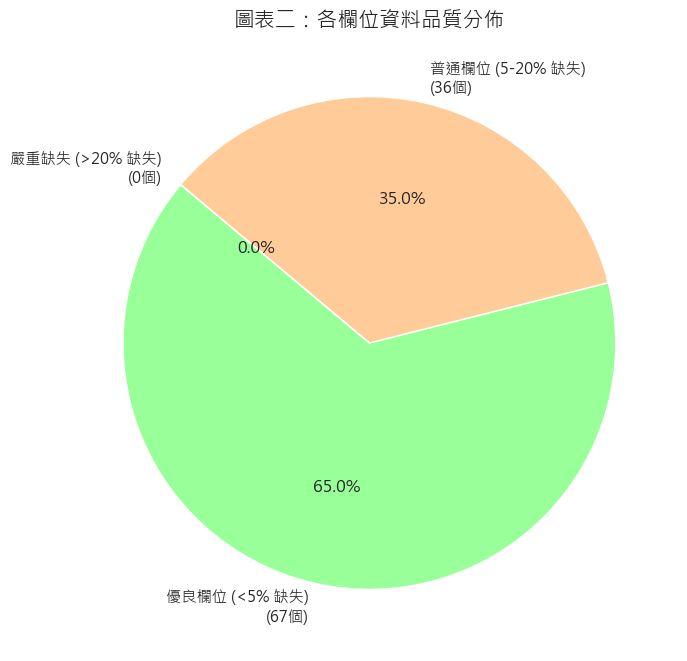

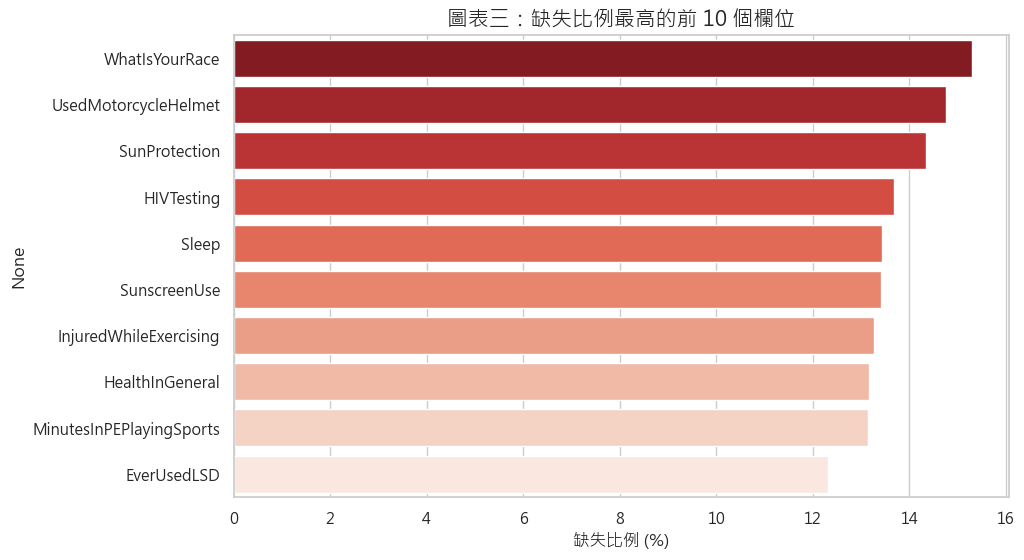

In [16]:
# --- 繪圖區塊：產出圖表並存入變數 ---

# --- 1. 全表資料完整度圓餅圖 ---
total_cells = df.size
null_cells = df.isnull().sum().sum()
filled_cells = total_cells - null_cells

plt.figure(figsize=(8, 8))
plt.pie([filled_cells, null_cells], 
        labels=['有效數據 (Filled)', '缺失數據 (Missing)'], 
        autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], 
        startangle=90, 
        explode=(0.1, 0))
plt.title('圖表一：2007 YRBS 全表數據完整度總覽', fontsize=15)
fig1 = plt.gcf() # 將此圖存入變數 fig1

# --- 2. 欄位品質分類圓餅圖 ---
missing_pct = (df.isnull().sum() / len(df)) * 100
good_cols = len(missing_pct[missing_pct <= 5])
medium_cols = len(missing_pct[(missing_pct > 5) & (missing_pct <= 20)])
bad_cols = len(missing_pct[missing_pct > 20])

plt.figure(figsize=(8, 8))
plt.pie([good_cols, medium_cols, bad_cols], 
        labels=[f'優良欄位 (<5% 缺失)\n({good_cols}個)', 
                f'普通欄位 (5-20% 缺失)\n({medium_cols}個)', 
                f'嚴重缺失 (>20% 缺失)\n({bad_cols}個)'], 
        autopct='%1.1f%%', 
        colors=['#99ff99','#ffcc99','#ff6666'], 
        startangle=140)
plt.title('圖表二：各欄位資料品質分佈', fontsize=15)
fig2 = plt.gcf() # 將此圖存入變數 fig2

# --- 3. 保留缺失前 10 名長條圖 ---
plt.figure(figsize=(10, 6))
top_10_missing = missing_report.head(10)
sns.barplot(x='缺失比例 (%)', y=top_10_missing.index, data=top_10_missing, palette='Reds_r', hue=top_10_missing.index, legend=False)
plt.title('圖表三：缺失比例最高的前 10 個欄位', fontsize=15)
plt.xlabel('缺失比例 (%)', fontsize=12)
fig3 = plt.gcf() # 將此圖存入變數 fig3

# 此格不寫 plt.show()，確保下一格能讀取 fig1, fig2, fig3

In [17]:
# --- 存檔區塊：獨立執行儲存動作 ---
import os

# 1. 確保目錄存在
save_path = '../outputs/figures/'
os.makedirs(save_path, exist_ok=True)

# 2. 使用變數名執行儲存 (對應 Cell A 的 fig1, fig2, fig3)
fig1.savefig(os.path.join(save_path, '01_overall_integrity_pie.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(save_path, '01_column_quality_pie.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(save_path, '01_top_missing_bar.png'), dpi=300, bbox_inches='tight')

print(f"✅ 成功！3 張圖表已存入：{save_path}")

✅ 成功！3 張圖表已存入：../outputs/figures/


In [5]:
# 存檔至 processed，保留所有原始欄位
output_path = '../data/processed/yrbs_full_inspected.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 全欄位檢查完成！完整資料已存至: {output_path}")

✅ 全欄位檢查完成！完整資料已存至: ../data/processed/yrbs_full_inspected.csv
